In [22]:
from pandas import read_excel, to_numeric,ExcelFile
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [23]:
dfs = {}

for archivo in Path("data/rc_data").glob("*.xls"):

    with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
        primera = f.readline().strip()

    dfs[archivo.stem] = read_excel(
    archivo,
    sheet_name="Sheet1",
    engine="xlrd",
    header=None
)

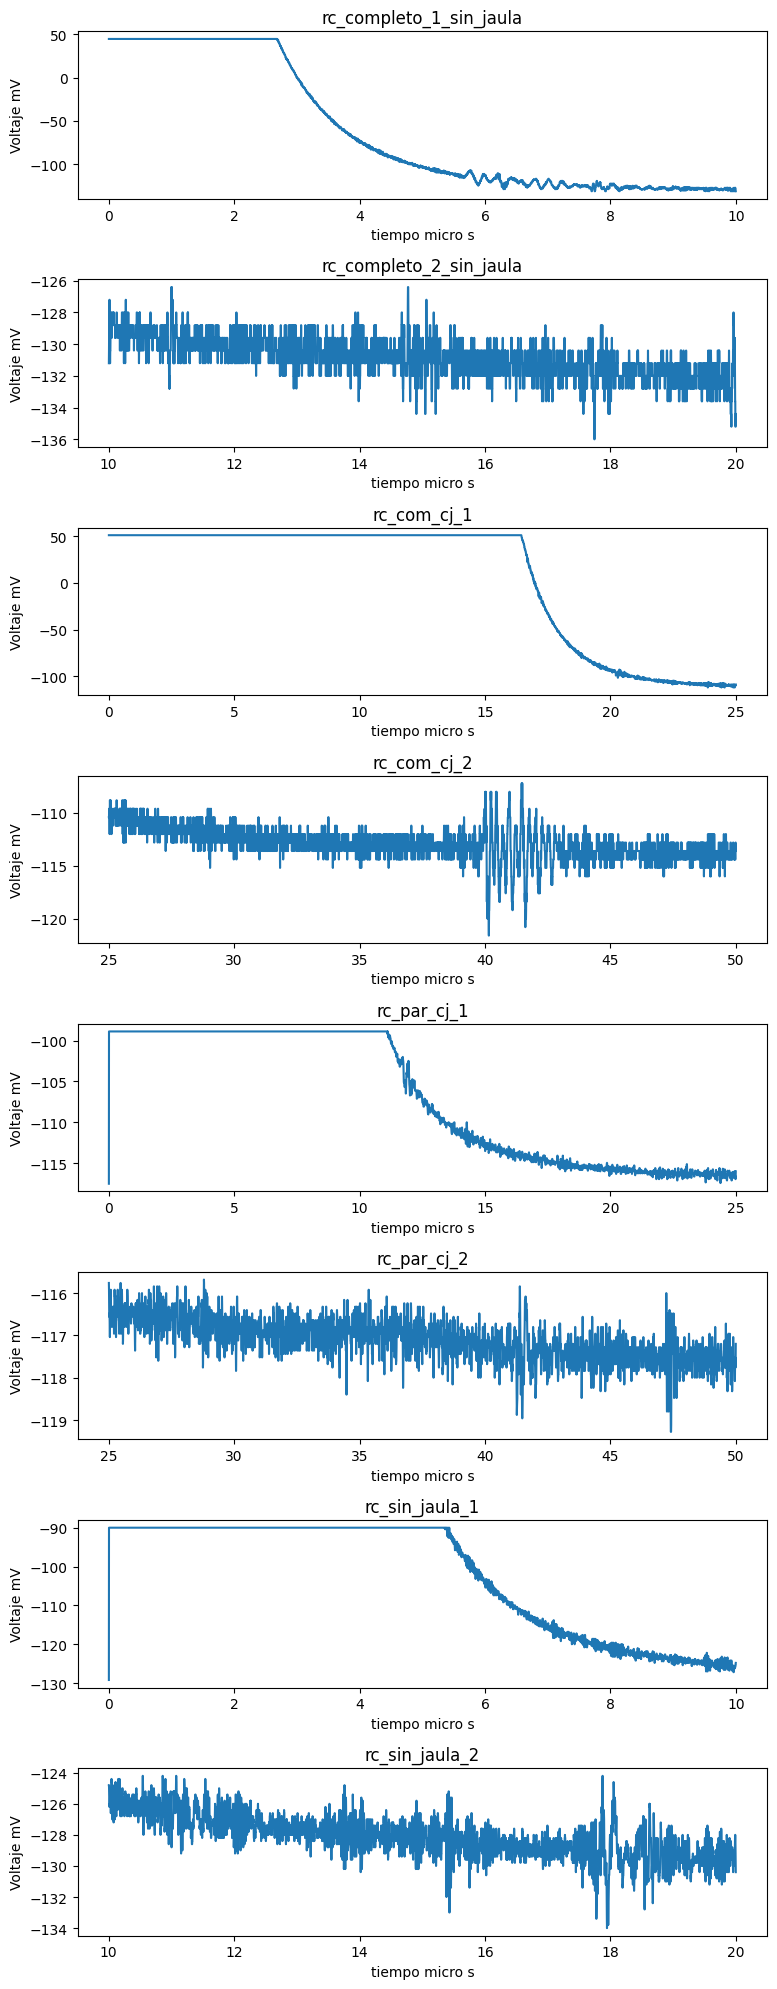

In [24]:
n = len(dfs)
fig, ax = plt.subplots(n,1, figsize = (8,20))

i = 0
for clave, df in dfs.items():
   delta_t = to_numeric(df.iloc[5,1].replace("uS", "").strip())
   ax[i].set_title(clave)
   t = (
      df.iloc[10:,0]*delta_t
   )

   f = (
      df.iloc[10:,1]
   )
   ax[i].set_xlabel('tiempo micro s')
   ax[i].set_ylabel('Voltaje mV')
   ax[i].plot(t,f)
   i+=1
# Ajustar el espaciado entre subplots
plt.tight_layout()
plt.show()


In [25]:
dfs = {}

for archivo in Path("data/rlc_data").glob("*.xls"):

    xls = ExcelFile(archivo, engine="xlrd")

    # tomar la primera hoja disponible
    sheet = xls.sheet_names[0]

    dfs[archivo.stem] = read_excel(
        archivo,
        sheet_name=sheet,
        engine="xlrd",
        header=None
    )

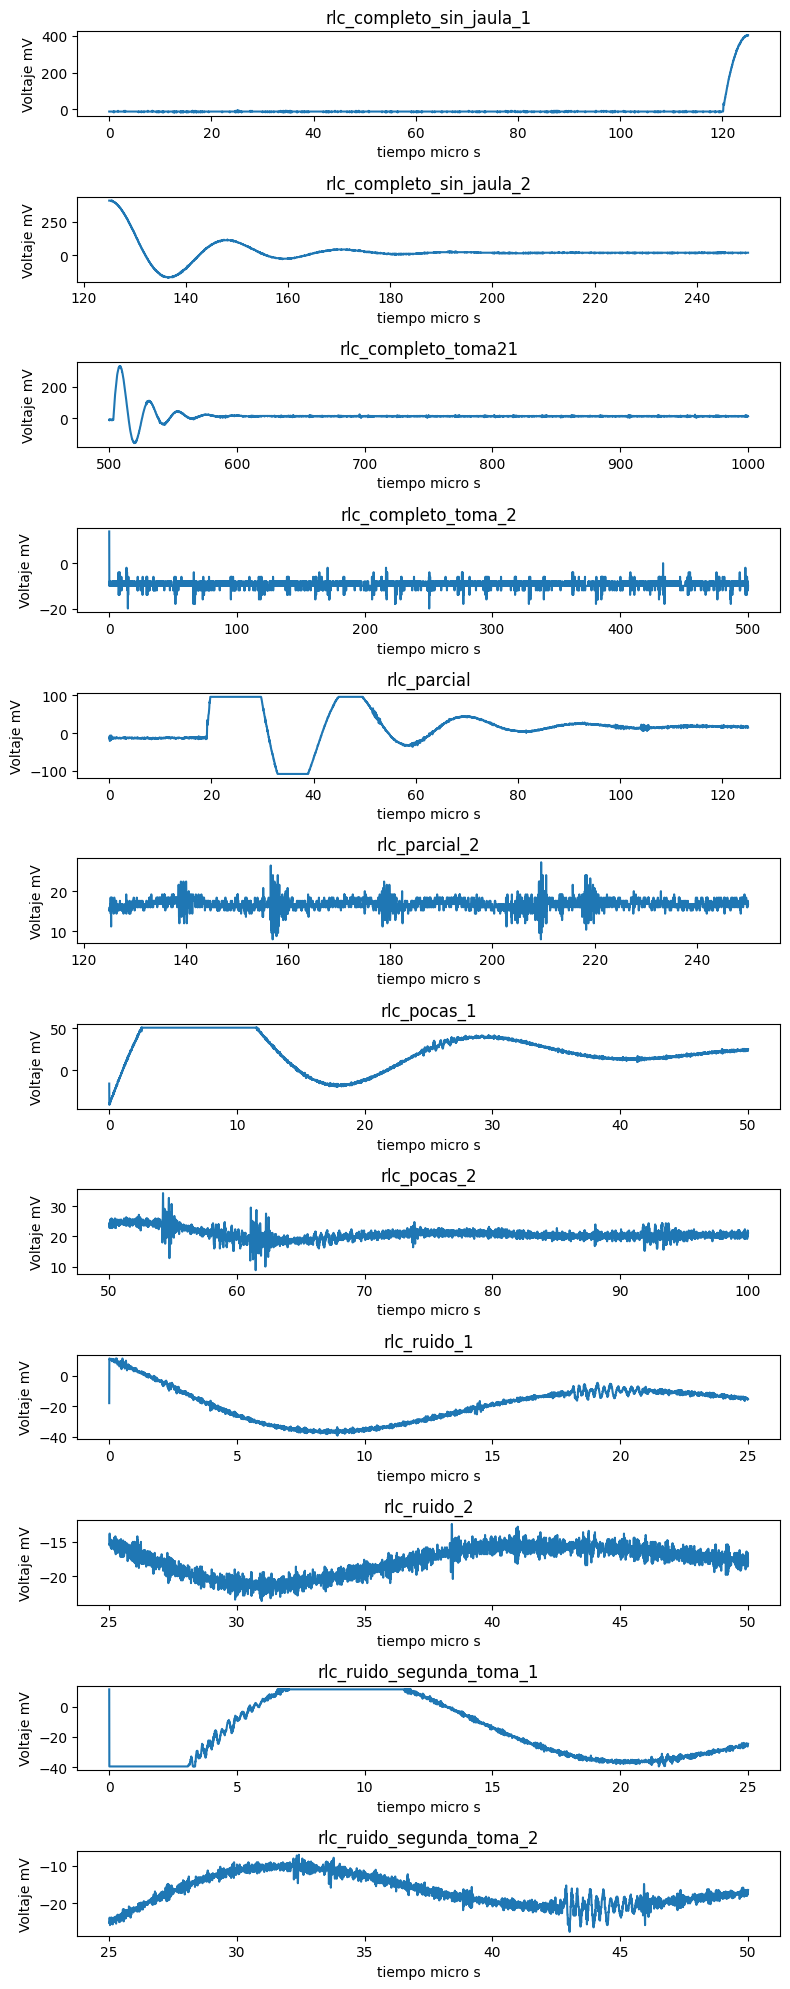

In [26]:
n = len(dfs)
fig, ax = plt.subplots(n,1, figsize = (8,20))

i = 0
for clave, df in dfs.items():
   delta_t = to_numeric(df.iloc[5,1].replace("uS", "").strip().replace(",", "."))
   ax[i].set_title(clave)
   t = (
      df.iloc[10:,0]*delta_t
   )

   f = (
      df.iloc[10:,1]
   )
   ax[i].set_xlabel('tiempo micro s')
   ax[i].set_ylabel('Voltaje mV')
   ax[i].plot(t,f)
   i+=1
# Ajustar el espaciado entre subplots
plt.tight_layout()
plt.show()
